In [1]:
# pip install scikit learn
!pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
df=pd.read_csv("digital_marketing_campaign_dataset[1].csv")
df2=df.copy()

7 questions

In [4]:
df2.shape

(8000, 20)

In [5]:
df2.sample(5)

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
2980,10980,42,Male,74841,Social Media,Retention,5609.174830,0.151857,0.042943,30,3.898411,11.957772,12,10,9,1,753,IsConfid,ToolConfid,1
6276,14276,32,Male,140921,Email,Retention,6713.506081,0.054437,0.110809,5,7.381511,9.942940,90,18,4,4,3334,IsConfid,ToolConfid,1
7701,15701,46,Female,27408,Social Media,Consideration,2983.837904,0.212211,0.197474,5,9.947636,10.649794,87,12,1,0,3736,IsConfid,ToolConfid,1
5501,13501,69,Female,97150,Referral,Conversion,8823.230698,0.011098,0.052146,41,3.708100,11.080777,16,11,6,7,2922,IsConfid,ToolConfid,1
6270,14270,46,Male,33031,PPC,Consideration,1353.781958,0.123406,0.149901,34,2.753287,9.512168,81,8,6,8,614,IsConfid,ToolConfid,1


In [6]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   str    
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   str    
 5   CampaignType         8000 non-null   str    
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   int64  
 16 

In [7]:
df2.isna().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

In [8]:
df2.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


In [9]:
df2.describe(include='str')

,Gender,CampaignChannel,CampaignType,AdvertisingPlatform,AdvertisingTool
count,8000,8000,8000,8000,8000
unique,2,5,4,1,1
top,Female,Referral,Conversion,IsConfid,ToolConfid
freq,4839,1719,2077,8000,8000


In [10]:
df2.duplicated().sum()

np.int64(0)

 univariate analysis

<Axes: xlabel='Conversion'>

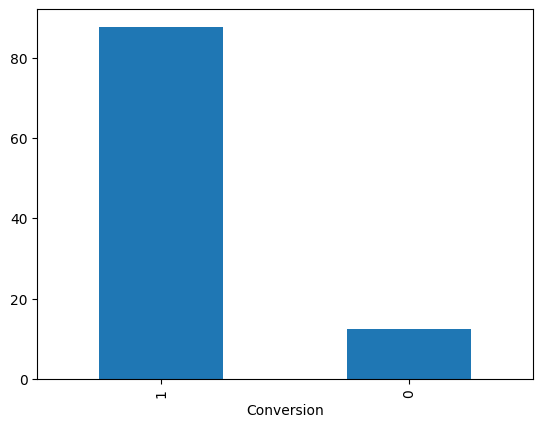

In [11]:
((df2["Conversion"].value_counts()*100)/8000).plot(kind='bar')

In [12]:
import seaborn as sns

<Axes: xlabel='count', ylabel='Gender'>

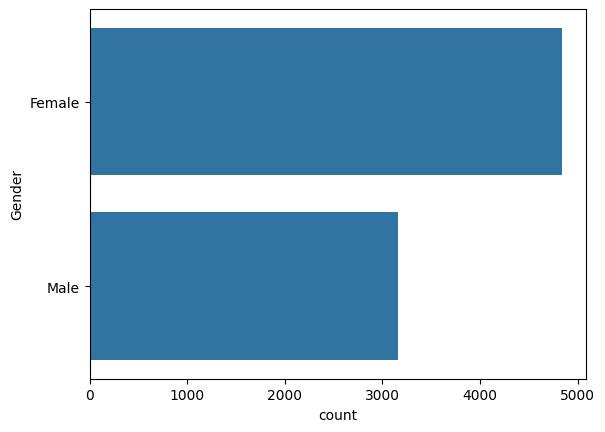

In [13]:
sns.countplot(df2["Gender"])

<Axes: >

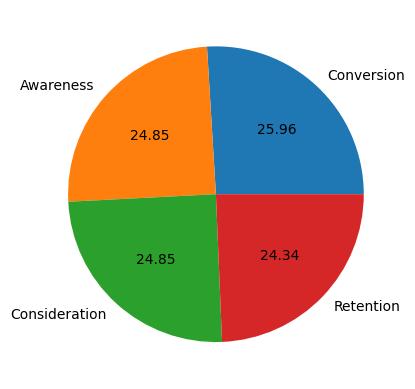

In [14]:
((df2["CampaignType"].value_counts()*100)/8000)
((df2["CampaignType"].value_counts()*100)/8000).plot(kind='pie',autopct='%.2f')


In [15]:
((df2["CampaignChannel"].value_counts()*100)/8000)

CampaignChannel
Referral        21.4875
PPC             20.6875
Email           19.4625
SEO             19.3750
Social Media    18.9875
Name: count, dtype: float64

(array([902., 723., 758., 803., 831., 736., 798., 751., 757., 941.]),
 array([18. , 23.1, 28.2, 33.3, 38.4, 43.5, 48.6, 53.7, 58.8, 63.9, 69. ]),
 <BarContainer object of 10 artists>)

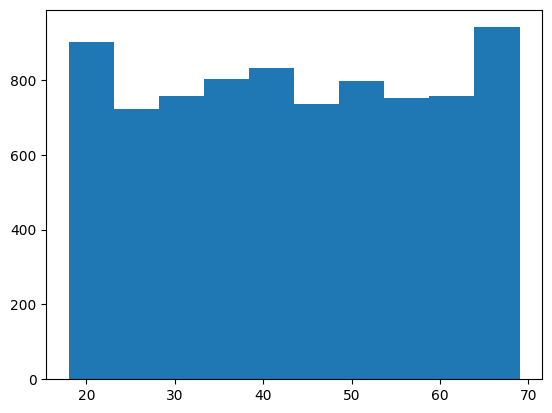

In [16]:
plt.hist(df2["Age"])

<Axes: xlabel='AdSpend', ylabel='Count'>

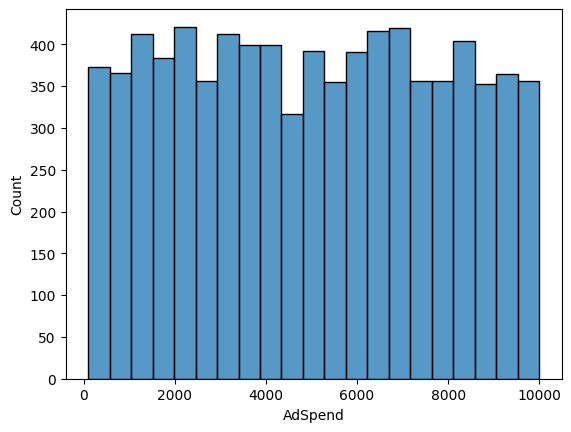

In [17]:
sns.histplot(df["AdSpend"])

<Axes: xlabel='ClickThroughRate', ylabel='Count'>

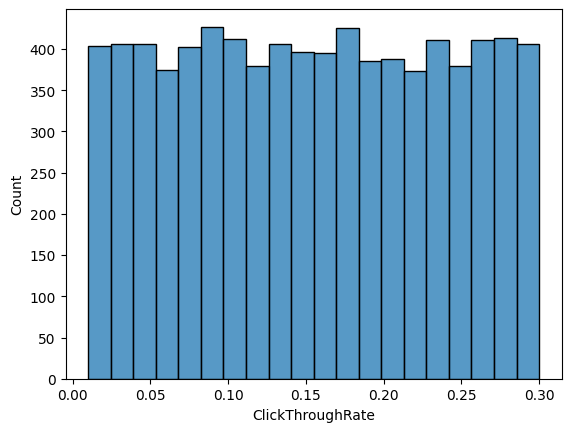

In [18]:
sns.histplot(df2["ClickThroughRate"])

<Axes: xlabel='WebsiteVisits', ylabel='Count'>

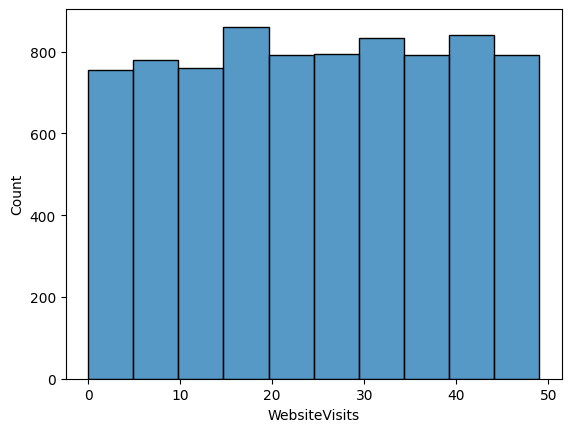

In [19]:
sns.histplot(df2['WebsiteVisits'],bins=10)

<Axes: ylabel='ConversionRate'>

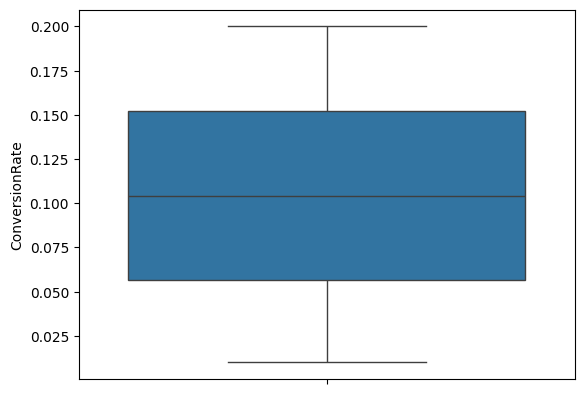

In [20]:
sns.boxplot(df2["ConversionRate"])

<Axes: xlabel='TimeOnSite', ylabel='Count'>

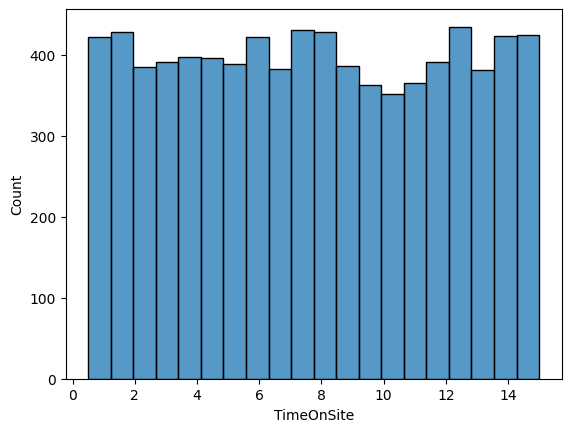

In [21]:
sns.histplot(df2["TimeOnSite"])

<Axes: xlabel='LoyaltyPoints', ylabel='Count'>

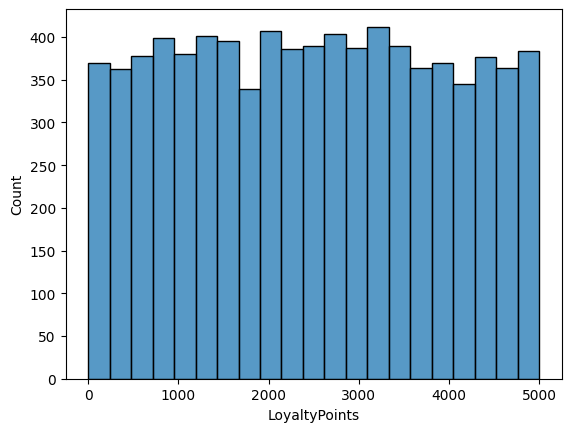

In [22]:
#sns.boxplot(df2['LoyaltyPoints'])
sns.histplot(df2['LoyaltyPoints'])

In [23]:
print(f'mean income:',df2["Income"].mean())
print(f'max income:',df2["Income"].max())
print(f'min income:',df2["Income"].min())


mean income: 84664.19675
max income: 149986
min income: 20014


multivariate analysis 

In [24]:
#keeping conversion the key feature or metrics to test in a/b metrics

In [25]:
# sns.pairplot(df2) # no as such relationship btw any two variables it shows uniform distribution all over

<Axes: xlabel='TimeOnSite', ylabel='AdSpend'>

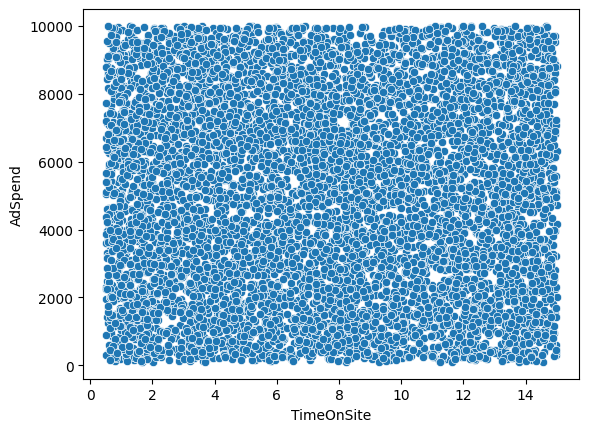

In [26]:
sns.scatterplot(x="TimeOnSite",y="AdSpend",data=df2)

<Axes: xlabel='Conversion', ylabel='AdSpend'>

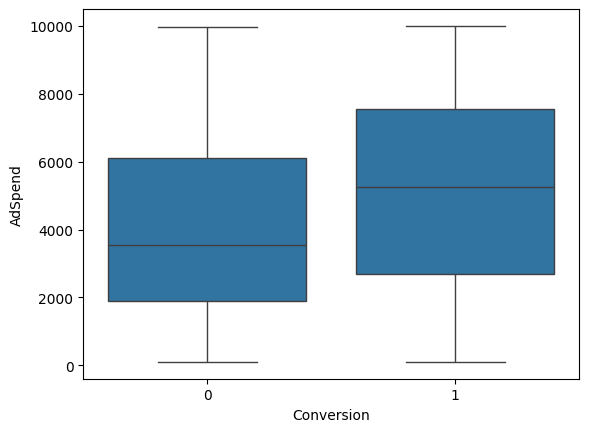

In [27]:
# adspend and conversion box plot
sns.boxplot(x='Conversion',y='AdSpend', data=df2)

SINCE THE DATA SHOWS VARIATION IN ADSPEND BTW CONV AND NON CONVE WE DID A STUDY PRIMARILY ON ADSPEND ON WHICH IT DEPEND NO EXTREME RELATION WITH NAY VARIABLE IS FOUND

<Axes: xlabel='TimeOnSite', ylabel='AdSpend'>

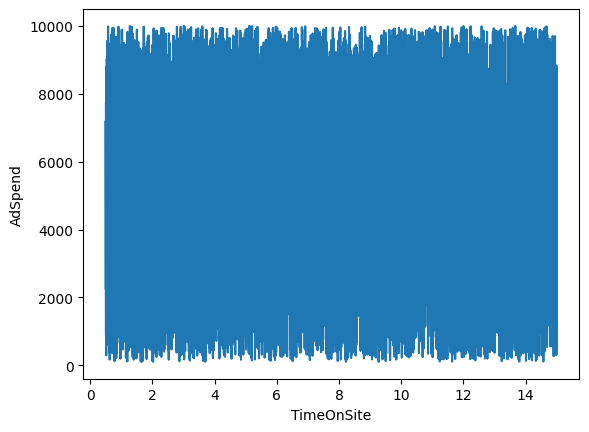

In [28]:
sns.lineplot(x='TimeOnSite',y='AdSpend',data=df2)

<Axes: xlabel='AdSpend', ylabel='SocialShares'>

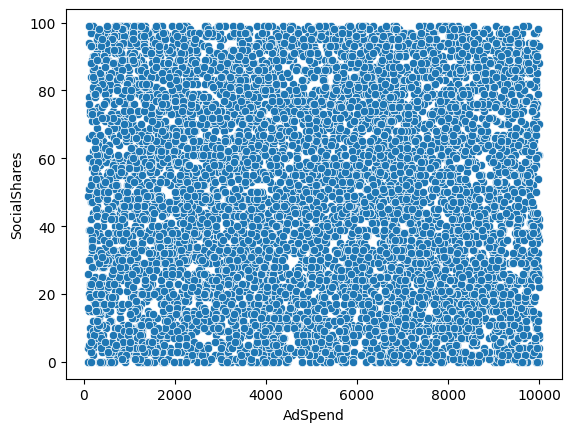

In [29]:
sns.scatterplot(x='AdSpend',y='SocialShares',data=df2)

<Axes: xlabel='AdSpend', ylabel='Count'>

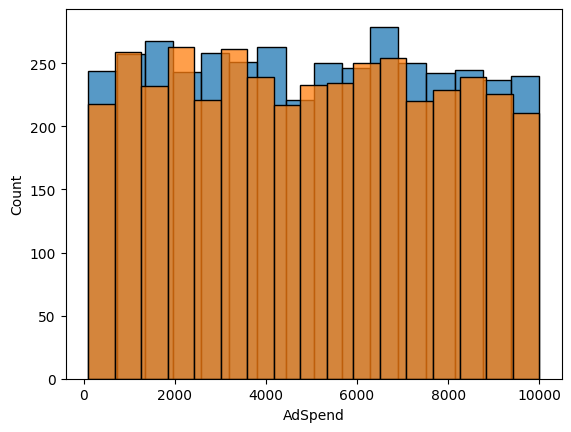

In [30]:
sns.histplot(df2[df2["Income"]>=85000]['AdSpend'])

sns.histplot(df2[df2["Income"]<85000]['AdSpend'])

In [31]:
df2['IncomeClass']=[1 if i >=85000 else 0 for i in df2['Income']]

In [32]:
print(f'total customer in each income group:',df2.groupby('IncomeClass')['CustomerID'].count())
print(f'avg ad spend on each group :',df2.groupby('IncomeClass')['AdSpend'].mean())
print(f'total adspend spend on each group:',round(df2.groupby('IncomeClass')['AdSpend'].sum()),4)


total customer in each income group: IncomeClass
0    4006
1    3994
Name: CustomerID, dtype: int64
avg ad spend on each group : IncomeClass
0    4994.066261
1    5007.844066
Name: AdSpend, dtype: float64
total adspend spend on each group: IncomeClass
0    20006229.0
1    20001329.0
Name: AdSpend, dtype: float64 4


In [33]:
# round((df2.groupby('Gender')["AdSpend"].sum()/df2['AdSpend'].sum()*100)),4#spend on all men and all female
round((df2.groupby('Gender')["AdSpend"].mean()/df2['AdSpend'].mean())*100,4)

Gender
Female    100.0827
Male       99.8734
Name: AdSpend, dtype: float64

<Axes: xlabel='AdSpend', ylabel='Count'>

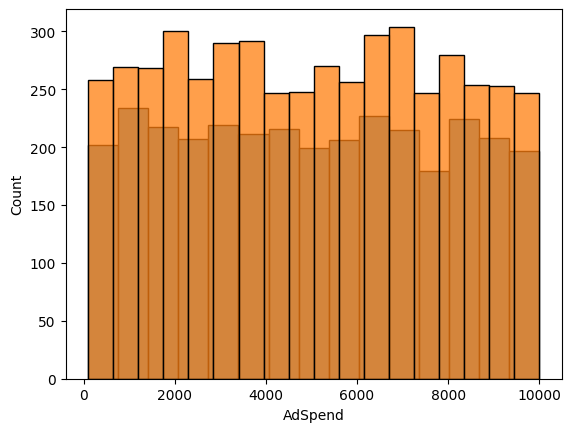

In [34]:
sns.histplot(df2[df2["Gender"]=='Male']['AdSpend'])

sns.histplot(df2[df2["Gender"]=='Female']['AdSpend'])

<Axes: xlabel='AdSpend', ylabel='Age'>

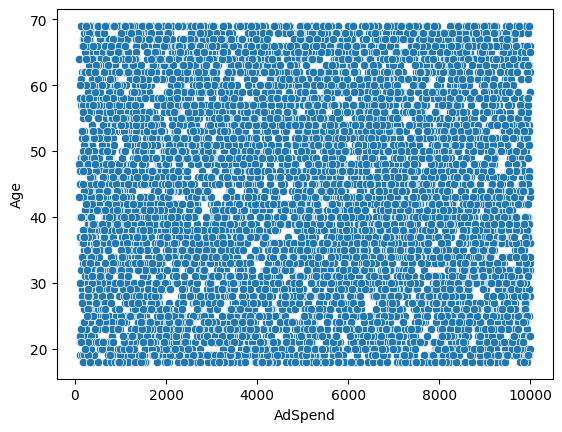

In [35]:
sns.scatterplot(x='AdSpend',y='Age',data=df2)

<Axes: xlabel='WebsiteVisits', ylabel='ClickThroughRate'>

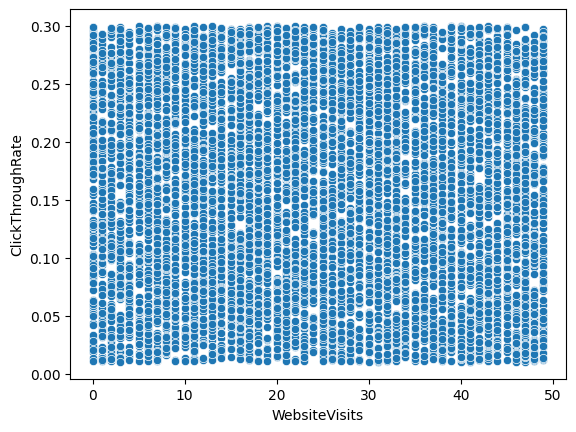

In [36]:
# websitevisits and clickthroughrate distplot
sns.scatterplot(x='WebsiteVisits',y='ClickThroughRate',data=df2)

<Axes: xlabel='Conversion', ylabel='PreviousPurchases'>

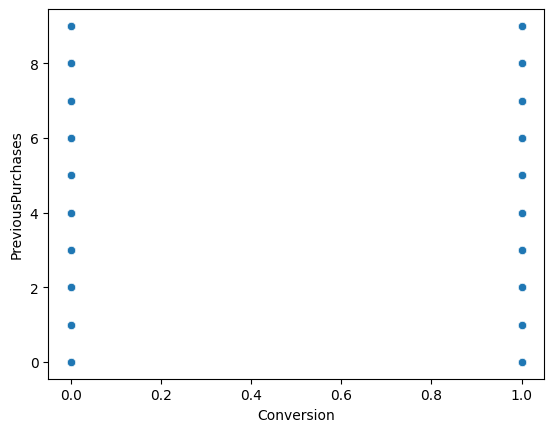

In [37]:
# previous purchase conversion box plot ,previous purchase conversion rate scatterplot
sns.scatterplot(x='Conversion',y='PreviousPurchases',data=df2)

<Axes: xlabel='PreviousPurchases', ylabel='ConversionRate'>

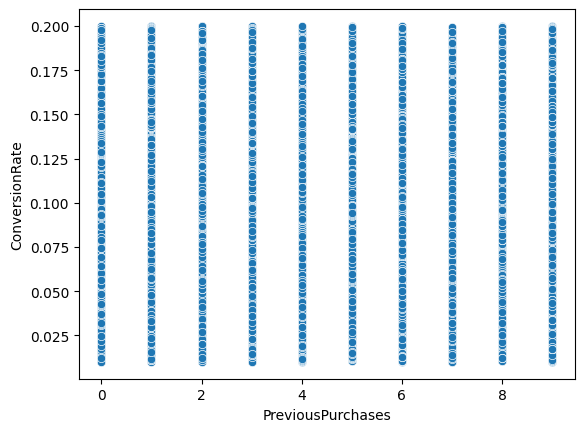

In [38]:
sns.scatterplot(x='PreviousPurchases',y='ConversionRate',data=df2)

<Axes: xlabel='CampaignChannel', ylabel='TimeOnSite'>

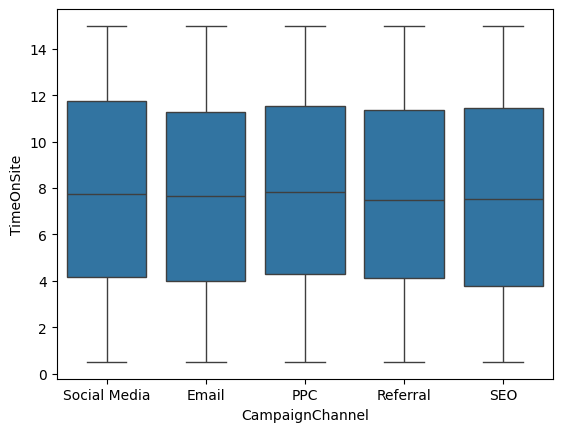

In [39]:
#time on site and campaign channel and campaign type boxplot
sns.boxplot(x='CampaignChannel',y='TimeOnSite',data=df2)

<Axes: xlabel='CampaignType', ylabel='AdSpend'>

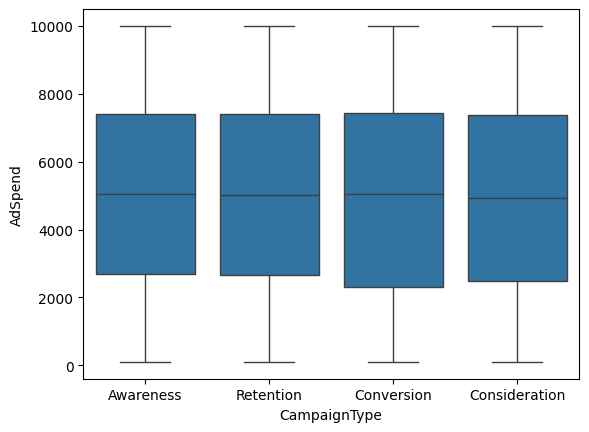

In [40]:
sns.boxplot(x='CampaignType',y='AdSpend',data=df2)


<Axes: xlabel='CampaignChannel', ylabel='AdSpend'>

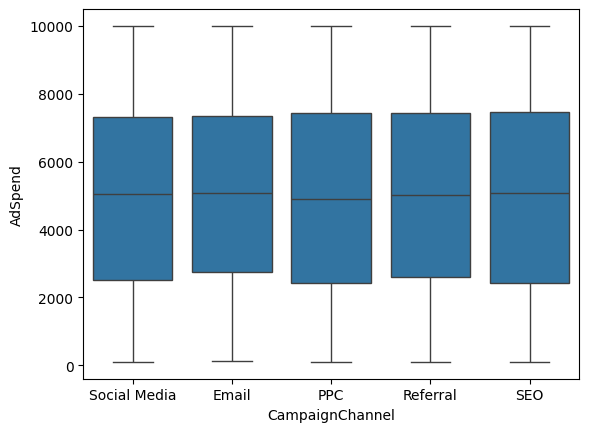

In [41]:
sns.boxplot(x='CampaignChannel',y='AdSpend',data=df2)


In [42]:
df2.groupby('Conversion')['CustomerID'].count()

Conversion
0     988
1    7012
Name: CustomerID, dtype: int64

Text(0.5, 1.0, 'Ad spend vs Conversion')

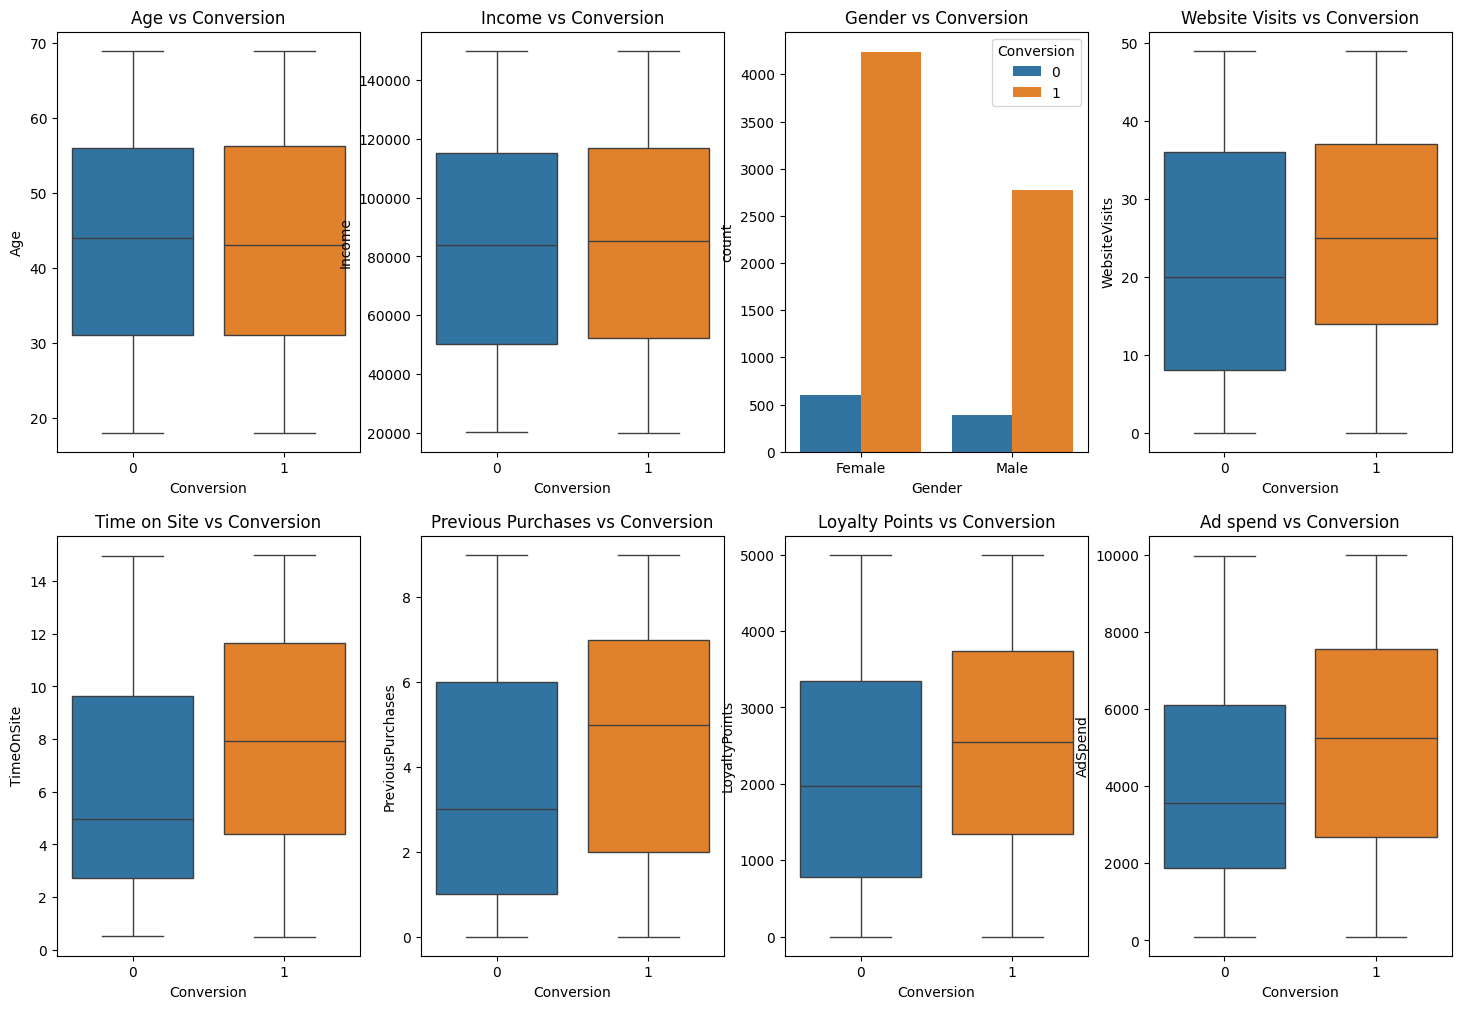

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

# Demographics
sns.boxplot(data=df, x='Conversion', y='Age', ax=axes[0], hue='Conversion', legend=False)
axes[0].set_title('Age vs Conversion')

sns.boxplot(data=df, x='Conversion', y='Income', ax=axes[1], hue='Conversion', legend=False)
axes[1].set_title('Income vs Conversion')

sns.countplot(data=df, x='Gender', hue='Conversion', ax=axes[2])
axes[2].set_title('Gender vs Conversion')

# Engagement
sns.boxplot(data=df, x='Conversion', y='WebsiteVisits', ax=axes[3], hue='Conversion', legend=False)
axes[3].set_title('Website Visits vs Conversion')

sns.boxplot(data=df, x='Conversion', y='TimeOnSite', ax=axes[4], hue='Conversion', legend=False)
axes[4].set_title('Time on Site vs Conversion')

# Historical data

sns.boxplot(data=df, x='Conversion', y='PreviousPurchases', ax=axes[5], hue='Conversion', legend=False)
axes[5].set_title('Previous Purchases vs Conversion')

#benefits and marketting
sns.boxplot(data=df, x='Conversion', y='LoyaltyPoints', ax=axes[6], hue='Conversion', legend=False)
axes[6].set_title('Loyalty Points vs Conversion')

sns.boxplot(data=df, x='Conversion', y='AdSpend', ax=axes[7], hue='Conversion', legend=False)
axes[7].set_title('Ad spend vs Conversion')

Text(0.5, 1.0, 'Ad spend vs Conversion')

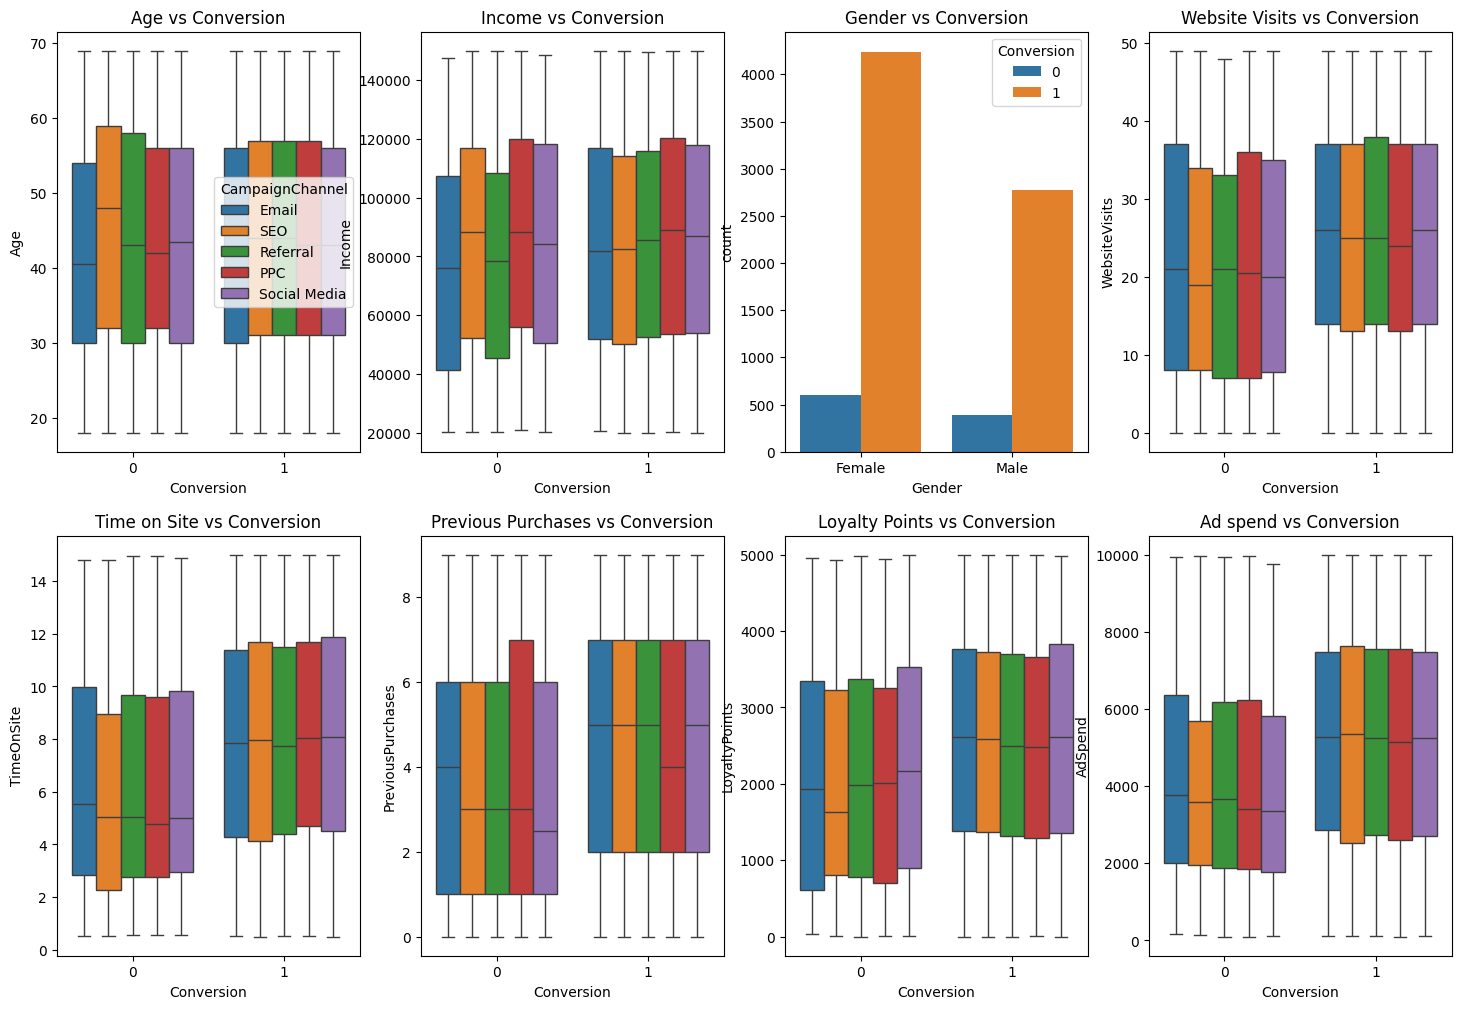

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

# Demographics
sns.boxplot(data=df, x='Conversion', y='Age', ax=axes[0], hue='CampaignChannel', legend=True)
axes[0].set_title('Age vs Conversion')

sns.boxplot(data=df, x='Conversion', y='Income', ax=axes[1], hue='CampaignChannel', legend=False)
axes[1].set_title('Income vs Conversion')

sns.countplot(data=df, x='Gender', hue='Conversion', ax=axes[2])
axes[2].set_title('Gender vs Conversion')

# Engagement
sns.boxplot(data=df, x='Conversion', y='WebsiteVisits', ax=axes[3], hue='CampaignChannel', legend=False)
axes[3].set_title('Website Visits vs Conversion')

sns.boxplot(data=df, x='Conversion', y='TimeOnSite', ax=axes[4], hue='CampaignChannel', legend=False)
axes[4].set_title('Time on Site vs Conversion')

# Historical data

sns.boxplot(data=df, x='Conversion', y='PreviousPurchases', ax=axes[5], hue='CampaignChannel', legend=False)
axes[5].set_title('Previous Purchases vs Conversion')

#benefits and marketting
sns.boxplot(data=df, x='Conversion', y='LoyaltyPoints', ax=axes[6], hue='CampaignChannel', legend=False)
axes[6].set_title('Loyalty Points vs Conversion')

sns.boxplot(data=df, x='Conversion', y='AdSpend', ax=axes[7], hue='CampaignChannel', legend=False)
axes[7].set_title('Ad spend vs Conversion')

In [45]:
print(df2.groupby('Conversion')['AdSpend'].median())
df2.groupby('Conversion')['AdSpend'].mean()


Conversion
0    3554.554979
1    5249.718686
Name: AdSpend, dtype: float64


Conversion
0    4058.398466
1    5133.750850
Name: AdSpend, dtype: float64

C:\Users\91952\AppData\Local\Temp\ipykernel_14180\2757487058.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2[df2['Conversion']==1]['PreviousPurchases'],hist=False)
C:\Users\91952\AppData\Local\Temp\ipykernel_14180\2757487058.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.di

<Axes: xlabel='PreviousPurchases', ylabel='Density'>

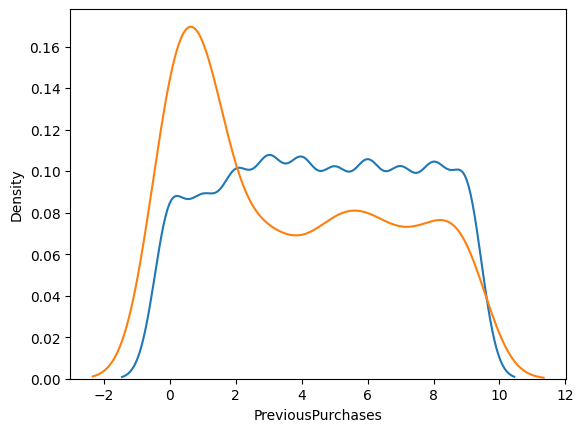

In [46]:
sns.distplot(df2[df2['Conversion']==1]['PreviousPurchases'],hist=False)
sns.distplot(df2[df2['Conversion']==0]['PreviousPurchases'],hist=False)


In [47]:
pd.crosstab(df2['CampaignChannel'],df2['Conversion'],normalize='index')*100

Conversion,0,1
CampaignChannel,,
Email,12.973667,87.026333
PPC,11.722054,88.277946
Referral,11.692845,88.307155
SEO,12.322581,87.677419
Social Media,13.166557,86.833443


In [48]:
round(df2.groupby('CampaignChannel')['AdSpend'].sum()/df2['AdSpend'].sum()*100),4

(CampaignChannel
 Email           20.0
 PPC             20.0
 Referral        22.0
 SEO             19.0
 Social Media    19.0
 Name: AdSpend, dtype: float64,
 4)

In [49]:
round(df2.groupby('CampaignChannel')['AdSpend'].median()),4

(CampaignChannel
 Email           5062.0
 PPC             4910.0
 Referral        5017.0
 SEO             5063.0
 Social Media    5037.0
 Name: AdSpend, dtype: float64,
 4)

# a/b testing

In [50]:
pd.crosstab(df2['CampaignChannel'],df2['Conversion'])

email_cc=df2[df2['CampaignChannel']=='Email']['Conversion'].reset_index().drop("index",axis=1)
referral_cc=df2[df2['CampaignChannel']=='Referral']['Conversion'].reset_index().drop("index",axis=1)
seo=df2[df2['CampaignChannel']=='SEO']['Conversion'].reset_index().drop("index",axis=1)
ppc=df2[df2['CampaignChannel']=='PPC']['Conversion'].reset_index().drop("index",axis=1)

In [51]:
smd_cc=df2[df2['CampaignChannel']=='Social Media']['Conversion'].reset_index().drop("index",axis=1)
# print(smd_cc)

In [52]:
print(f'conversion for email marketting channel:\n', email_cc.groupby("Conversion").size())
print(f'conversion for sm_cc marketting channel:\n',smd_cc.groupby("Conversion").size())

conversion for email marketting channel:
 Conversion
0     202
1    1355
dtype: int64
conversion for sm_cc marketting channel:
 Conversion
0     200
1    1319
dtype: int64


In [53]:
email_converted=df2.groupby("CampaignChannel")["Conversion"].sum().loc["Email"]
ssd_converted=df2.groupby("CampaignChannel")["Conversion"].sum().loc["Social Media"]
print(f"No of conversion through email marketting is ",email_converted)
print(f"No of conversion through Social Media marketting is ",ssd_converted)

No of conversion through email marketting is  1355
No of conversion through Social Media marketting is  1319


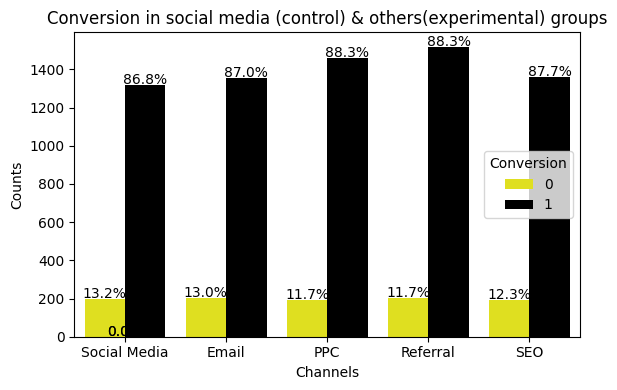

In [54]:
# visualization 
palette={0:"yellow",1:"black"} #assuming 1 is convert and 0 is non convert
#plotting the conversion nd non conversion distribution across each group
plt.figure(figsize=(6,4))
ax=sns.countplot(x="CampaignChannel",data=df2,hue="Conversion",palette=palette)
plt.title("Conversion in social media (control) & others(experimental) groups")
plt.xlabel("Channels")
plt.ylabel("Counts")

campaign_count=df2.groupby(["CampaignChannel"]).size()
conversion_count=df2.groupby(["CampaignChannel","Conversion"]).size().reset_index(name="count")

channels=list(df2["CampaignChannel"].unique())
n_channel=len(channels)
for i, p in enumerate(ax.patches):
    height=p.get_height()
    #locating the conv to currect bar
    channel=channels[i%n_channel]
    total=campaign_count[channel]
    perc=100*height/total
    ax.text(p.get_x() + p.get_width()/2.,height+5,f'{perc:.1f}%',ha="center",color='black',fontsize=10)

plt.tight_layout()
plt.show()
    
    

                                                                                    

# Parameters of model from Power Analysis
### beta=Type II error
### alpha=Level of significance/type 1 error
### delta=Minimum detectable effect

In [55]:
power_of_test=.80
print("Power of test 1-beta is:",power_of_test)
alpha=0.05
print(f'Level if significance for the test:',alpha)
delta=4 
print(f'Minimum Dtetctable Effect is %:',delta)
Sample_size_calculated=1200
print(f'Sample size required for the test for each variation is around or more:',Sample_size_calculated)

Power of test 1-beta is: 0.8
Level if significance for the test: 0.05
Minimum Dtetctable Effect is %: 4
Sample size required for the test for each variation is around or more: 1200


# calculating pooled estimates for Conversion

In [56]:
email_count=(df2.groupby("CampaignChannel")["Conversion"]).count().loc["Email"]
ssd_count=(df2.groupby("CampaignChannel")["Conversion"]).count().loc["Social Media"]


In [57]:
email_p_hat=email_converted/email_count
ssd_p_hat=ssd_converted/ssd_count
print(f'Proportion of converted through email campaign is :',email_p_hat)
print(f'Proportion of converted through Social Media campaign is :',ssd_p_hat)


Proportion of converted through email campaign is : 0.8702633269107257
Proportion of converted through Social Media campaign is : 0.8683344305464121


In [58]:
p_pooled_hat=(email_converted+ssd_converted)/(email_count+ssd_count)
print(f"Pooled probability of convert for email and social media campaign is",p_pooled_hat)

Pooled probability of convert for email and social media campaign is 0.8693107932379714


### Pooled Variance

In [59]:
pooled_Variance= p_pooled_hat*(1-p_pooled_hat)*(1/email_count+1/ssd_count)
print(f'Pooled Variance is',pooled_Variance)


Pooled Variance is 0.00014775927055484493


### Calculating Standard Error and Test Statistics

In [60]:
SE=np.sqrt(pooled_Variance)
print(f'Standard error is:',SE)

Standard error is: 0.012155627114832247


In [61]:
test_statistics=(email_p_hat-ssd_p_hat)/SE
print(f'The calculated test_statistics(z_test) is:',test_statistics)

The calculated test_statistics(z_test) is: 0.158683410250382


In [62]:
z_critical_value=norm.ppf(1-alpha/2)
print(f'The calculated z critical value is:',z_critical_value)

The calculated z critical value is: 1.959963984540054


### calculating p-value

In [63]:
p_value=2*norm.sf(abs(test_statistics))
def is_statistical_significant(p_value,alpha):
    print(f'The p-value for 2 sample Z-test is:',p_value)
    if p_value < alpha:
        print('There is a statistical significance,indicating that the observed differences in Conversion between group are unlikely to have occured by chance alone.This suggest that the changes in experimentgroup ')
    else:
        print('There is no statistical significance, indicating that the observed differences in Conversion between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence')

is_statistical_significant(p_value,alpha)  

The p-value for 2 sample Z-test is: 0.8739183092577776
There is no statistical significance, indicating that the observed differences in Conversion between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence


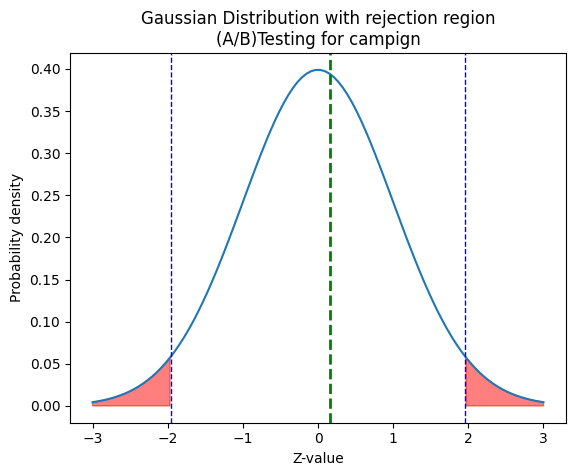

In [64]:
#Normal Distribution
#defining parameters
mu=0
sigma=1
x=np.linspace(mu-3*sigma,mu+3*sigma,100)
y=norm.pdf(x,mu,sigma)
#plotting the std normal distribution
plt.plot(x,y,label="Standard Normal Distribution")
#shading therejection region for 2 tail test
plt.fill_between(x,y,where=(x > z_critical_value)|(x< -z_critical_value),color="red",alpha=0.5,label='Rejection Region')
#adding test_statisitcs
plt.axvline(test_statistics,color="green",linestyle="dashed",linewidth=2,label=f"TestStatisitics={test_statistics:.2f}")
#adding z_critical_value
plt.axvline(z_critical_value,color="blue",linestyle="dashed",linewidth=1,label=f"Z-critical={z_critical_value:.2f}")
plt.axvline(-z_critical_value,color='blue',linestyle='dashed',linewidth=1)

#title and labels
plt.xlabel("Z-value")
plt.ylabel("Probability density")
plt.title("Gaussian Distribution with rejection region\n(A/B)Testing for campign")
plt.legend
plt.show()


## Group 2: PPC VS Social Media

In [65]:
ppc_count=df2.groupby("CampaignChannel")["Conversion"].count().loc["PPC"]
ppc_converted=df2.groupby("CampaignChannel")["Conversion"].sum().loc["PPC"]

print(f"There are {ppc_converted} out of {ppc_count} through PPC Campaign Channel")
ppc_p_hat=ppc_converted/ppc_count
print(f"The proportion of converted is:",ppc_p_hat)

p_pooled_hat2=(ppc_converted+ssd_converted)/(ppc_count+ssd_count)
print(f"Pooled probability of converts for PPC and Social Media campaign is:",p_pooled_hat2)

pooled_variance2=p_pooled_hat2*(1-p_pooled_hat2)*(1/ppc_count+1/ssd_count)
print(f"Pooled variance is:",pooled_variance2)

SE_2=np.sqrt(pooled_variance2)
print(f"Standard error is:",SE_2)

test_stats_2=(ssd_p_hat-ppc_p_hat)/SE_2
print(f"Test statistic for 2nd group is:",test_stats_2)

z_critical_2=norm.ppf(1-alpha/2)
print(f"Critical value for z test for 2nd group is:",z_critical_2)

p_value_2=2*norm.sf(abs(test_stats_2))

is_statistical_significant(p_value_2,alpha)

There are 1461 out of 1655 through PPC Campaign Channel
The proportion of converted is: 0.8827794561933535
Pooled probability of converts for PPC and Social Media campaign is: 0.8758664146187776
Pooled variance is: 0.00013727085014182824
Standard error is: 0.011716264342435615
Test statistic for 2nd group is: -1.2329036990589537
Critical value for z test for 2nd group is: 1.959963984540054
The p-value for 2 sample Z-test is: 0.21761169521401835
There is no statistical significance, indicating that the observed differences in Conversion between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence


## Group 3: SEO VS Social Media

In [66]:
seo_count=df2.groupby("CampaignChannel")["Conversion"].count().loc["SEO"]
seo_converted=df2.groupby("CampaignChannel")["Conversion"].sum().loc["SEO"]

print(f"There are {seo_converted} out of {seo_count} through PPC Campaign Channel")
seo_p_hat=seo_converted/seo_count
print(f"The proportion of converted is:",seo_p_hat)

p_pooled_hat3=(seo_converted+ssd_converted)/(seo_count+ssd_count)
print(f"Pooled probability of converts for SEO and Social Media campaign is:",p_pooled_hat3)

pooled_variance3=p_pooled_hat3*(1-p_pooled_hat3)*(1/seo_count+1/ssd_count)
print(f"Pooled variance is:",pooled_variance3)

SE_3=np.sqrt(pooled_variance3)
print(f"Standard error is:",SE_3)

test_stats_3=(ssd_p_hat-seo_p_hat)/SE_3
print(f"Test statistic for 3nd group is:",test_stats_3)

z_critical_3=norm.ppf(1-alpha/2)
print(f"Critical value for z test for 3nd group is:",z_critical_3)

p_value_3=2*norm.sf(abs(test_stats_3))
print(f"p-value for test statisitics is:",p_value_3)
is_statistical_significant(p_value_3,alpha)

There are 1359 out of 1550 through PPC Campaign Channel
The proportion of converted is: 0.8767741935483871
Pooled probability of converts for SEO and Social Media campaign is: 0.8725969371130662
Pooled variance is: 0.00014491087192813982
Standard error is: 0.012037893168164428
Test statistic for 3nd group is: -0.7010996761704889
Critical value for z test for 3nd group is: 1.959963984540054
p-value for test statisitics is: 0.4832408124207249
The p-value for 2 sample Z-test is: 0.4832408124207249
There is no statistical significance, indicating that the observed differences in Conversion between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence


## GROUP 4: Refferal VS Social Media

In [67]:
ref_count=df2.groupby("CampaignChannel")["Conversion"].count().loc["Referral"]
ref_converted=df2.groupby("CampaignChannel")["Conversion"].sum().loc["Referral"]

print(f"There are {ref_converted} out of {ref_count} through Referral Campaign Channel")
ref_p_hat=ref_converted/ref_count
print(f"The proportion of converted is:",ref_p_hat)

p_pooled_hat4=(ref_converted+ssd_converted)/(ref_count+ssd_count)
print(f"Pooled probability of converts for Referral and Social Media campaign is:",p_pooled_hat4)

pooled_variance4=p_pooled_hat4*(1-p_pooled_hat4)*(1/ref_count+1/ssd_count)
print(f"Pooled variance is:",pooled_variance4)

SE_4=np.sqrt(pooled_variance4)
print(f"Standard error is:",SE_4)

test_stats_4=(ssd_p_hat-ref_p_hat)/SE_4
print(f"Test statistic for 4nd group is:",test_stats_4)

z_critical_4=norm.ppf(1-alpha/2)
print(f"Critical value for z test for 4nd group is:",z_critical_4)

p_value_4=2*norm.sf(abs(test_stats_4))
print(f"p-value for test statisitics is:",p_value_4)
is_statistical_significant(p_value_4,alpha)

There are 1518 out of 1719 through Referral Campaign Channel
The proportion of converted is: 0.8830715532286213
Pooled probability of converts for Referral and Social Media campaign is: 0.8761581222977146
Pooled variance is: 0.0001345529467701852
Standard error is: 0.011599695977489461
Test statistic for 4nd group is: -1.2704749082052016
Critical value for z test for 4nd group is: 1.959963984540054
p-value for test statisitics is: 0.20391551521145135
The p-value for 2 sample Z-test is: 0.20391551521145135
There is no statistical significance, indicating that the observed differences in Conversion between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence


# Since no campaign channels make any significant difference in conversion when compared with social media.
## The study was expanded to check the statistical significance in price variation among channels.

Calculating the aggregate functions of ad spend

In [68]:
sm_price=round(df2.groupby("CampaignChannel")["AdSpend"].agg(total="sum",average="mean",median="median").loc["Social Media"]),4
print(f"Social Media stats:\n",sm_price)
ref_price=round(df2.groupby("CampaignChannel")["AdSpend"].agg(total="sum",average="mean",median="median").loc["Referral"]),4
print(f"Referral stats:\n",ref_price)
ppc_price=round(df2.groupby("CampaignChannel")["AdSpend"].agg(total="sum",average="mean",median="median").loc["PPC"]),4
print(f"PPC stats:\n",ppc_price)
seo_price=round(df2.groupby("CampaignChannel")["AdSpend"].agg(total="sum",average="mean",median="median").loc["SEO"]),4
print(f"SEO stats:\n",seo_price)
email_price=round(df2.groupby("CampaignChannel")["AdSpend"].agg(total="sum",average="mean",median="median").loc["Email"]),4
print(f"Email  stats:\n",email_price)


Social Media stats:
 (total      7542323.0
average       4965.0
median        5037.0
Name: Social Media, dtype: float64, 4)
Referral stats:
 (total      8653519.0
average       5034.0
median        5017.0
Name: Referral, dtype: float64, 4)
PPC stats:
 (total      8199237.0
average       4954.0
median        4910.0
Name: PPC, dtype: float64, 4)
SEO stats:
 (total      7740904.0
average       4994.0
median        5063.0
Name: SEO, dtype: float64, 4)
Email  stats:
 (total      7871576.0
average       5056.0
median        5062.0
Name: Email, dtype: float64, 4)


Power analysis

In [69]:
power_of_test=.80
print("Power of test 1-beta is:",power_of_test)
alpha=0.05
print(f'Level if significance for the test:',alpha)
delta=6 
print(f'Minimum Dtetctable Effect is %:',delta)
Sample_size_calculated=1400
print(f'Sample size required for the test for each variation is around or more:',Sample_size_calculated)

Power of test 1-beta is: 0.8
Level if significance for the test: 0.05
Minimum Dtetctable Effect is %: 6
Sample size required for the test for each variation is around or more: 1400


calculating mean and standard deviation for adspend in each campaign channel

In [70]:
sm_std=df2.groupby("CampaignChannel")["AdSpend"].std().loc["Social Media"]
sm_mean=df2.groupby("CampaignChannel")["AdSpend"].mean().loc["Social Media"]
print("Standard deviation and mean for social media ad spend is:\n",sm_std,sm_mean)

ref_std=df2.groupby("CampaignChannel")["AdSpend"].std().loc["Referral"]
ref_mean=df2.groupby("CampaignChannel")["AdSpend"].mean().loc["Referral"]
print("Standard deviation for referral ad spend is:\n",ref_std)

ppc_std=df2.groupby("CampaignChannel")["AdSpend"].std().loc["PPC"]
ppc_mean=df2.groupby("CampaignChannel")["AdSpend"].mean().loc["PPC"]
print("Standard deviation for PPC ad spend is:\n",sm_std)

seo_std=df2.groupby("CampaignChannel")["AdSpend"].std().loc["SEO"]
seo_mean=df2.groupby("CampaignChannel")["AdSpend"].mean().loc["SEO"]
print("Standard deviation for SEO ad spend is:\n",seo_std)

email_std=df2.groupby("CampaignChannel")["AdSpend"].std().loc["Email"]
email_mean=df2.groupby("CampaignChannel")["AdSpend"].mean().loc["Email"]
print("Standard deviation for Email ad spend is:\n",email_std)

Standard deviation and mean for social media ad spend is:
 2812.860322840413 4965.321428014535
Standard deviation for referral ad spend is:
 2836.3522521557124
Standard deviation for PPC ad spend is:
 2812.860322840413
Standard deviation for SEO ad spend is:
 2875.028843967428
Standard deviation for Email ad spend is:
 2785.0678606978568


In [71]:
SE_price=np.sqrt(sm_std**2/ssd_count+email_std**2/email_count)
print("Standard error btw 1st group is:",SE_price)

z_test=(email_mean-sm_mean)/SE_price
print("Z test score for group 1st is:",z_test)

z_crit_1=norm.ppf(1-alpha/2)
print("z critical point (left of which lies 97.5 area) for group 1st is:",z_crit_1)

p_value_price=2*norm.sf(abs(z_test))

def is_statistical_significant_price(p_value_price,alpha):
    print(f'The p-value for 2 sample Z-test is:',p_value_price)
    if p_value_price < alpha:
        print('There is a statistical significance,indicating that the observed differences in Adspend between group are unlikely to have occured by chance alone.This suggest that the changes in experimentgroup ')
    else:
        print('There is no statistical significance, indicating that the observed differences in Adspend between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence')

is_statistical_significant_price(p_value_price,alpha)

Standard error btw 1st group is: 100.94836424867573
Z test score for group 1st is: 0.8943467771699627
z critical point (left of which lies 97.5 area) for group 1st is: 1.959963984540054
The p-value for 2 sample Z-test is: 0.3711363794425955
There is no statistical significance, indicating that the observed differences in Adspend between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence


In [72]:
SE_price2=np.sqrt(sm_std**2/ssd_count+ref_std**2/ref_count)
print("Standard error btw 1st group is:",SE_price2)

z_test2=(ref_mean-sm_mean)/SE_price2
print("Z test score for group 2nd is:",z_test2)

z_crit_2=norm.ppf(1-alpha/2)
print("z critical point (left of which lies 97.5 area) for group 2nd is:",z_crit_2)

p_value_price2=2*norm.sf(abs(z_test2))

def is_statistical_significant_price(p_value_price,alpha):
    print(f'The p-value for 2 sample Z-test is:',p_value_price)
    if p_value_price < alpha:
        print('There is a statistical significance,indicating that the observed differences in Adspend between group are unlikely to have occured by chance alone.This suggest that the changes in experiment group are significant enough to be considered. ')
    else:
        print('There is no statistical significance, indicating that the observed differences in Adspend between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence')

is_statistical_significant_price(p_value_price2,alpha)

Standard error btw 1st group is: 99.44242285163753
Z test score for group 2nd is: 0.6910617587878469
z critical point (left of which lies 97.5 area) for group 2nd is: 1.959963984540054
The p-value for 2 sample Z-test is: 0.4895267308476928
There is no statistical significance, indicating that the observed differences in Adspend between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence


In [73]:
SE_price3=np.sqrt(sm_std**2/ssd_count+seo_std**2/seo_count)
print("Standard error btw 3rd group is:",SE_price3)

z_test3=(seo_mean-sm_mean)/SE_price3
print("Z test score for group 3rd is:",z_test3)

z_crit_3=norm.ppf(1-alpha/2)
print("z critical point (left of which lies 97.5 area) for group 3rd is:",z_crit_3)

p_value_price3=2*norm.sf(abs(z_test3))

def is_statistical_significant_price(p_value_price,alpha):
    print(f'The p-value for 2 sample Z-test is:',p_value_price)
    if p_value_price < alpha:
        print('There is a statistical significance,indicating that the observed differences in Adspend between group are unlikely to have occured by chance alone.This suggest that the changes in experimentgroup ')
    else:
        print('There is no statistical significance, indicating that the observed differences in Adspend between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence')

is_statistical_significant_price(p_value_price3,alpha)

Standard error btw 3rd group is: 102.67219108970583
Z test score for group 3rd is: 0.2806028035292056
z critical point (left of which lies 97.5 area) for group 3rd is: 1.959963984540054
The p-value for 2 sample Z-test is: 0.7790150654904539
There is no statistical significance, indicating that the observed differences in Adspend between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence


In [74]:
SE_price4=np.sqrt(sm_std**2/ssd_count+ppc_std**2/ppc_count)
print("Standard error btw 4th group is:",SE_price4)

z_test4=(ppc_mean-sm_mean)/SE_price4
print("Z test score for group 4th is:",z_test4)

z_crit_4=norm.ppf(1-alpha/2)
print("z critical point (left of which lies 97.5 area) for group 4th is:",z_crit_4)

p_value_price4=2*norm.sf(abs(z_test4))

def is_statistical_significant_price(p_value_price,alpha):
    print(f'The p-value for 2 sample Z-test is:',p_value_price)
    if p_value_price < alpha:
        print('There is a statistical significance,indicating that the observed differences in Adspend between group are unlikely to have occured by chance alone.This suggest that the changes in experimentgroup ')
    else:
        print('There is no statistical significance, indicating that the observed differences in Adspend between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence')

is_statistical_significant_price(p_value_price4,alpha)

Standard error btw 4th group is: 101.08172221616154
Z test score for group 4th is: -0.1098090427394476
z critical point (left of which lies 97.5 area) for group 4th is: 1.959963984540054
The p-value for 2 sample Z-test is: 0.9125608193485815
There is no statistical significance, indicating that the observed differences in Adspend between groups could have occured by chance.This implies that changes in email marketting campaign do not have a statistical evidence


## heterogenity analysis

In [75]:
df3=df2.copy()


In [76]:
df3["Age_level"]=["young" if a < 30 else "adult" if a > 30 and a <= 50 else "old" for a in df3["Age"]]

In [77]:
df3["c_segment"]=["Repeated" if b >=10 and c > 0 else "New" for b,c in zip(df3["TimeOnSite"],df3["PreviousPurchases"])]

In [78]:
# df3["segment"]=np.where(
# (df3["TimeOnSite"] >=10)  & (df3["PreviousPurchases"]>= 0),"Repeated","New")

In [79]:
pd.crosstab([df3["Age_level"],df3["c_segment"]],df3["Conversion"],normalize="index")

Conversion                  0         1
Age_level c_segment                    
adult     New        0.147398  0.852602
          Repeated   0.064682  0.935318
old       New        0.142791  0.857209
          Repeated   0.081229  0.918771
young     New        0.145320  0.854680
          Repeated   0.079279  0.920721

In [80]:
conv_df = df3[df3["CampaignType"] == "Conversion"]

pd.crosstab(
    [conv_df["c_segment"], conv_df["CampaignChannel"]],
    conv_df["Conversion"],
    normalize="index"
)

Conversion                        0         1
c_segment CampaignChannel                    
New       Email            0.072917  0.927083
          PPC              0.061889  0.938111
          Referral         0.080386  0.919614
          SEO              0.062731  0.937269
          Social Media     0.078431  0.921569
Repeated  Email            0.054688  0.945312
          PPC              0.057143  0.942857
          Referral         0.044776  0.955224
          SEO              0.053435  0.946565
          Social Media     0.071429  0.928571

In [81]:
pd.crosstab([df3["c_segment"],df3["CampaignType"]],df3["Conversion"],normalize="index")

Conversion                      0         1
c_segment CampaignType                     
New       Awareness      0.169920  0.830080
          Consideration  0.168482  0.831518
          Conversion     0.071229  0.928771
          Retention      0.173977  0.826023
Repeated  Awareness      0.085950  0.914050
          Consideration  0.090016  0.909984
          Conversion     0.055814  0.944186
          Retention      0.065630  0.934370

In [82]:
import statsmodels.formula.api as smf


In [83]:
model2=smf.logit(
    "Conversion ~ CampaignChannel*c_segment",
    data=df3
).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.368071
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Conversion   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7990
Method:                           MLE   Df Model:                            9
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                 0.01543
Time:                        10:23:02   Log-Likelihood:                -2944.6
converged:                       True   LL-Null:                       -2990.7
Covariance Type:            nonrobust   LLR p-value:                 5.575e-16
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept             

<Axes: xlabel='c_segment', ylabel='Conversion'>

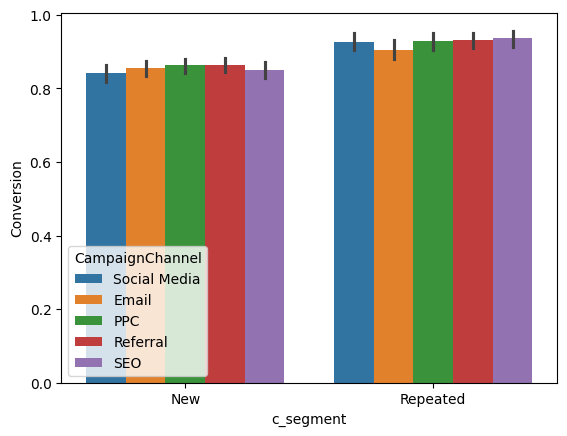

In [84]:
sns.barplot(x="c_segment",y="Conversion",data=df3,hue="CampaignChannel")

## Campaign Type

In [85]:
model_b=smf.logit(
    "Conversion~CampaignType",
    data=df3
).fit()
print(model_b.summary())

Optimization terminated successfully.
         Current function value: 0.367934
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Conversion   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7996
Method:                           MLE   Df Model:                            3
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                 0.01580
Time:                        10:23:04   Log-Likelihood:                -2943.5
converged:                       True   LL-Null:                       -2990.7
Covariance Type:            nonrobust   LLR p-value:                 2.348e-20
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         1.7795      0.064     27.886      0.

In [86]:
model_b1=smf.logit(
    "Conversion~CampaignType*Gender",
    data=df3
).fit()
print(model_b1.summary())

Optimization terminated successfully.
         Current function value: 0.367289
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Conversion   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7992
Method:                           MLE   Df Model:                            7
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                 0.01753
Time:                        10:23:04   Log-Likelihood:                -2938.3
converged:                       True   LL-Null:                       -2990.7
Covariance Type:            nonrobust   LLR p-value:                 1.084e-19
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                               

<Axes: xlabel='Gender', ylabel='Conversion'>

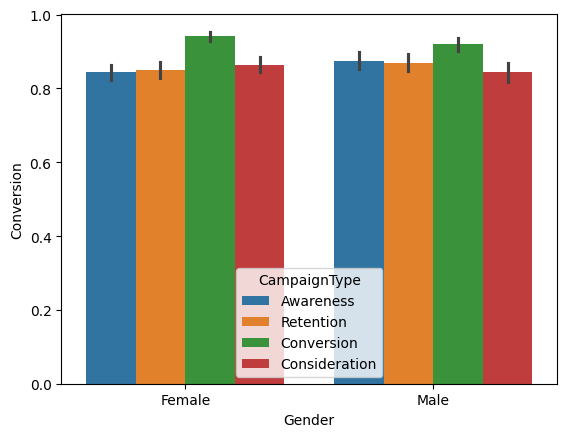

In [87]:
sns.barplot(x="Gender",y="Conversion",data=df3,hue="CampaignType")

In [88]:
model_b2=smf.logit(
    "Conversion~CampaignType*Age_level",
    data=df3
).fit()
print(model_b2.summary())

Optimization terminated successfully.
         Current function value: 0.367761
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Conversion   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7988
Method:                           MLE   Df Model:                           11
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                 0.01626
Time:                        10:23:06   Log-Likelihood:                -2942.1
converged:                       True   LL-Null:                       -2990.7
Covariance Type:            nonrobust   LLR p-value:                 6.170e-16
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                       

<Axes: xlabel='Age_level', ylabel='Conversion'>

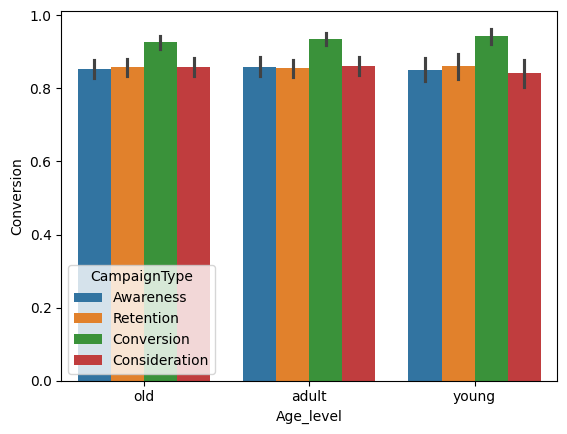

In [89]:
sns.barplot(x="Age_level",y="Conversion",data=df3,hue="CampaignType")

In [90]:
model3=smf.logit(
    "Conversion~ CampaignType*c_segment",
    data=df3
).fit()
print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.361995
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Conversion   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7992
Method:                           MLE   Df Model:                            7
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                 0.03169
Time:                        10:23:09   Log-Likelihood:                -2896.0
converged:                       True   LL-Null:                       -2990.7
Covariance Type:            nonrobust   LLR p-value:                 1.887e-37
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------
Intercept                 

<Axes: xlabel='c_segment', ylabel='Conversion'>

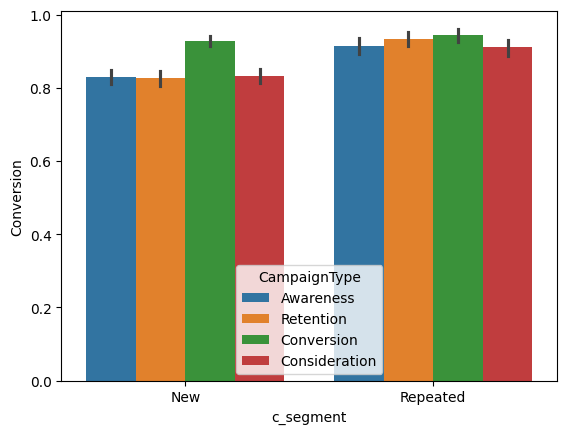

In [91]:
sns.barplot(x="c_segment",y="Conversion",data=df3,hue="CampaignType")

In [92]:
model_c=smf.logit(
    "Conversion~CampaignType",
    data=df3
).fit()
print(model_c.summary())

Optimization terminated successfully.
         Current function value: 0.367934
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Conversion   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7996
Method:                           MLE   Df Model:                            3
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                 0.01580
Time:                        10:23:10   Log-Likelihood:                -2943.5
converged:                       True   LL-Null:                       -2990.7
Covariance Type:            nonrobust   LLR p-value:                 2.348e-20
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         1.7795      0.064     27.886      0.

<Axes: xlabel='CampaignType', ylabel='Conversion'>

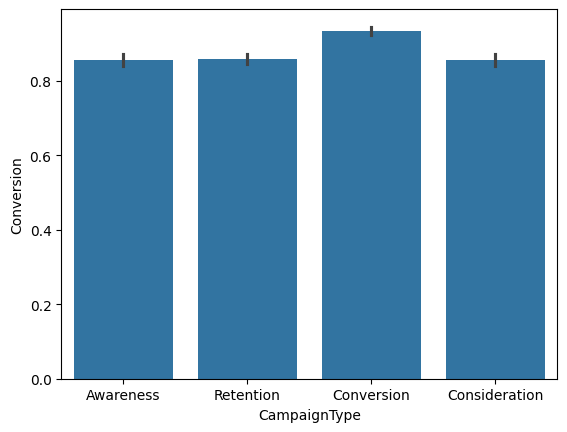

In [93]:
sns.barplot(x="CampaignType",y="Conversion",data=df3)

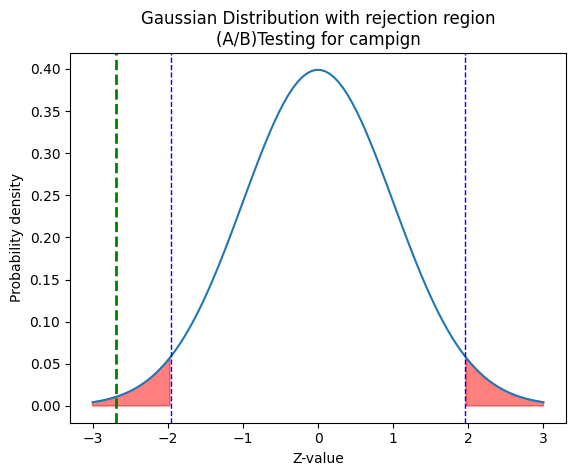

In [94]:
mu=0
sigma=1
x=np.linspace(mu-3*sigma,mu+3*sigma,100)
y=norm.pdf(x,mu,sigma)
#plotting the std normal distribution
plt.plot(x,y,label="Standard Normal Distribution")
#shading therejection region for 2 tail test
plt.fill_between(x,y,where=(x > z_critical_value)|(x< -z_critical_value),color="red",alpha=0.5,label='Rejection Region')
#adding test_statisitcs
plt.axvline(-2.688,color="green",linestyle="dashed",linewidth=2,label="TestStatisitics=-2.688:.2f")
#adding z_critical_value
plt.axvline(z_critical_value,color="blue",linestyle="dashed",linewidth=1,label=f"Z-critical={z_critical_value:.2f}")
plt.axvline(-z_critical_value,color='blue',linestyle='dashed',linewidth=1)

#title and labels
plt.xlabel("Z-value")
plt.ylabel("Probability density")
plt.title("Gaussian Distribution with rejection region\n(A/B)Testing for campign")
plt.legend
plt.show()